In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
# Dimensionality reduction / clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set(style='whitegrid')

In [4]:
!pip install kagglehub


   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/loan-status-prediction")

print("Path to dataset files:", path)
import os
os.listdir(path)

df = pd.read_csv(path + '/loan_data.csv')
df.head()

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\bhavikjikadara\loan-status-prediction\versions\1


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [4]:
df.drop(columns=['Loan_ID'], inplace=True)

In [5]:
## Categorical columns → fill with mode
cat_cols = ['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']

In [6]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
## Numerical columns → fill with median
num_cols = ['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
#removing outliers
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    df = remove_outliers(df, col)

In [9]:
#Encode categorical variables

# Create encoder instance
le = LabelEncoder()

# List of categorical columns
cat_cols = ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [11]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [12]:
#split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
importances = rf.feature_importances_
feature_names = X.columns

In [15]:
# Create dataframe of importance
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [16]:
print(feat_imp)

              Feature  Importance
9      Credit_History    0.332324
5     ApplicantIncome    0.191570
7          LoanAmount    0.163181
6   CoapplicantIncome    0.095653
10      Property_Area    0.049761
8    Loan_Amount_Term    0.043350
2          Dependents    0.035641
1             Married    0.027344
3           Education    0.023194
4       Self_Employed    0.020574
0              Gender    0.017409


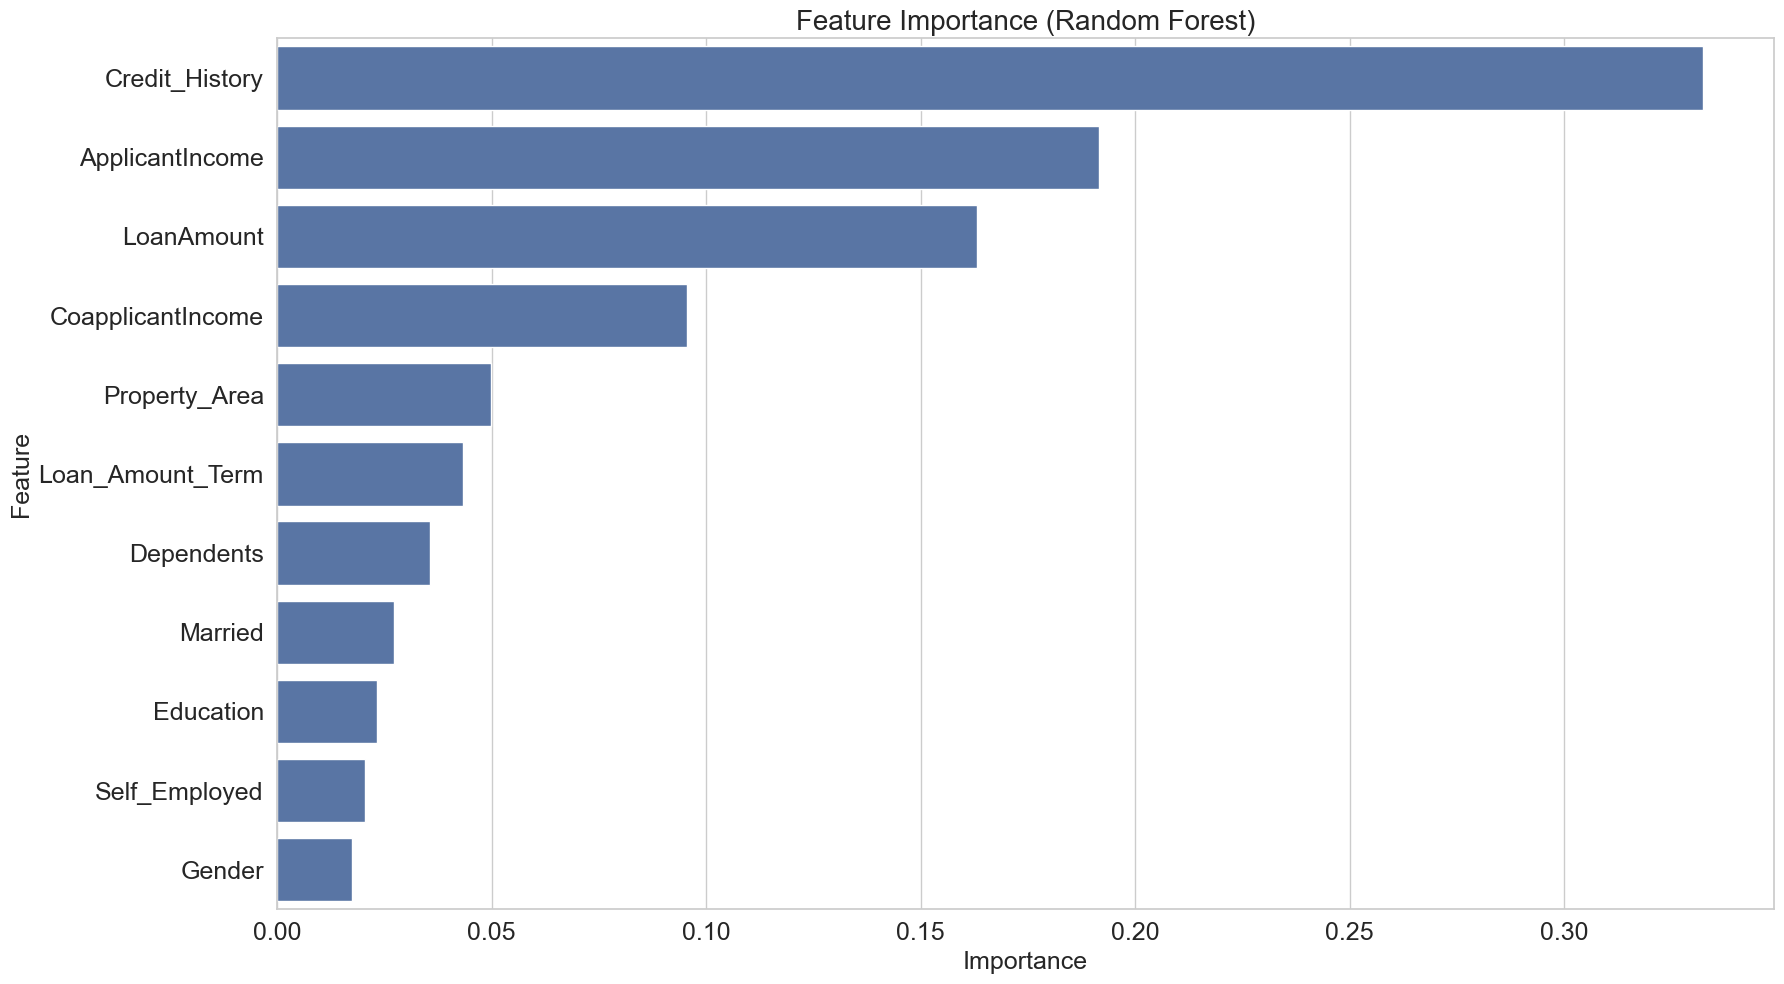

In [23]:
plt.figure(figsize=(18, 10))
sns.barplot(x='Importance', y='Feature', data=feat_imp, orient='h')
plt.title("Feature Importance (Random Forest)", fontsize=20)
plt.xlabel("Importance", fontsize=18)
plt.ylabel("Feature", fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

In [20]:
y_pred = rf.predict(X_test)

In [21]:
# Accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8732394366197183


In [58]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[12  8]
 [ 1 50]]


In [59]:
# Classification Report
cr = classification_report(y_test, y_pred)
print("\nClassification Report:\n", cr)


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.60      0.73        20
           1       0.86      0.98      0.92        51

    accuracy                           0.87        71
   macro avg       0.89      0.79      0.82        71
weighted avg       0.88      0.87      0.86        71



In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8450704225352113

Confusion Matrix:
 [[11  9]
 [ 2 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.55      0.67        20
           1       0.84      0.96      0.90        51

    accuracy                           0.85        71
   macro avg       0.85      0.76      0.78        71
weighted avg       0.85      0.85      0.83        71



In [61]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.8591549295774648

Confusion Matrix:
 [[10 10]
 [ 0 51]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67        20
           1       0.84      1.00      0.91        51

    accuracy                           0.86        71
   macro avg       0.92      0.75      0.79        71
weighted avg       0.88      0.86      0.84        71



In [62]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8450704225352113

Confusion Matrix:
 [[13  7]
 [ 4 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.65      0.70        20
           1       0.87      0.92      0.90        51

    accuracy                           0.85        71
   macro avg       0.82      0.79      0.80        71
weighted avg       0.84      0.85      0.84        71



In [63]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    max_samples=1.0,
    bootstrap=True,
    random_state=42
)

bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("Bagging Classifier Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))

Bagging Classifier Accuracy: 0.8450704225352113

Confusion Matrix:
 [[12  8]
 [ 3 48]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69        20
           1       0.86      0.94      0.90        51

    accuracy                           0.85        71
   macro avg       0.83      0.77      0.79        71
weighted avg       0.84      0.85      0.84        71



In [64]:
print("Model Comparison:")
print("Random Forest Accuracy:", accuracy)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Model Comparison:
Random Forest Accuracy: 0.8732394366197183
XGBoost Accuracy: 0.8450704225352113
AdaBoost Accuracy: 0.8591549295774648
Gradient Boosting Accuracy: 0.8450704225352113
Bagging Accuracy: 0.8450704225352113


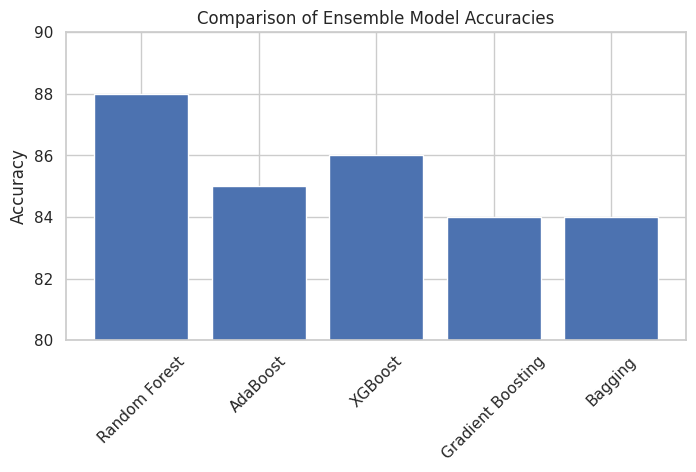

In [65]:
model_names = ['Random Forest', 'AdaBoost', 'XGBoost', 'Gradient Boosting', 'Bagging']
accuracies   = [88, 85, 86, 84, 84]

plt.figure(figsize=(8,4))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.ylim(80, 90)
plt.title("Comparison of Ensemble Model Accuracies")
plt.xticks(rotation=45)
plt.show()

In [66]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred_et))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_et))
print("\nClassification Report:\n", classification_report(y_test, y_pred_et))


Extra Trees Accuracy: 0.8591549295774648

Confusion Matrix:
 [[11  9]
 [ 1 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.55      0.69        20
           1       0.85      0.98      0.91        51

    accuracy                           0.86        71
   macro avg       0.88      0.77      0.80        71
weighted avg       0.87      0.86      0.85        71



In [70]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))


Stacking Accuracy: 0.8169014084507042

Confusion Matrix:
 [[13  7]
 [ 6 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.65      0.67        20
           1       0.87      0.88      0.87        51

    accuracy                           0.82        71
   macro avg       0.77      0.77      0.77        71
weighted avg       0.81      0.82      0.82        71



In [71]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('svc', SVC(probability=True))
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_vote))


Voting Classifier Accuracy: 0.7887323943661971

Confusion Matrix:
 [[ 5 15]
 [ 0 51]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.25      0.40        20
           1       0.77      1.00      0.87        51

    accuracy                           0.79        71
   macro avg       0.89      0.62      0.64        71
weighted avg       0.84      0.79      0.74        71



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=42
)

cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.1 MB/s eta 0:00:00
CatBoost Accuracy: 0.8732394366197183

Confusion Matrix:
 [[13  7]
 [ 2 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.65      0.74        20
           1       0.88      0.96      0.92        51

    accuracy                           0.87        71
   macro avg       0.87      0.81      0.83        71
weighted avg       0.87      0.87      0.87        71



In [75]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm.fit(X_train, y_train)
y_pred_lgb = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 201, number of negative: 82
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 220
[LightGBM] [Info] Number of data points in the train set: 283, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.710247 -> initscore=0.896586
[LightGBM] [Info] Start training from score 0.896586
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

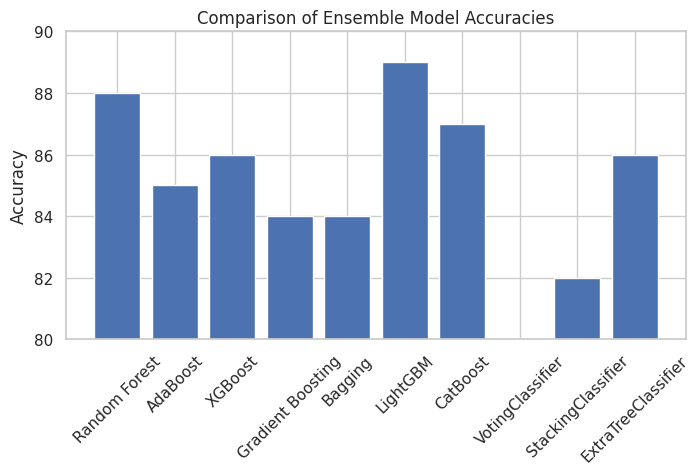

In [76]:
model_names = ['Random Forest', 'AdaBoost', 'XGBoost', 'Gradient Boosting', 'Bagging', 'LightGBM', 'CatBoost', 'VotingClassifier', 'StackingClassifier', 'ExtraTreeClassifier' ]
accuracies   = [88, 85, 86, 84, 84, 89, 87, 79, 82, 86  ]

plt.figure(figsize=(8,4))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.ylim(80, 90)
plt.title("Comparison of Ensemble Model Accuracies")
plt.xticks(rotation=45)
plt.show()

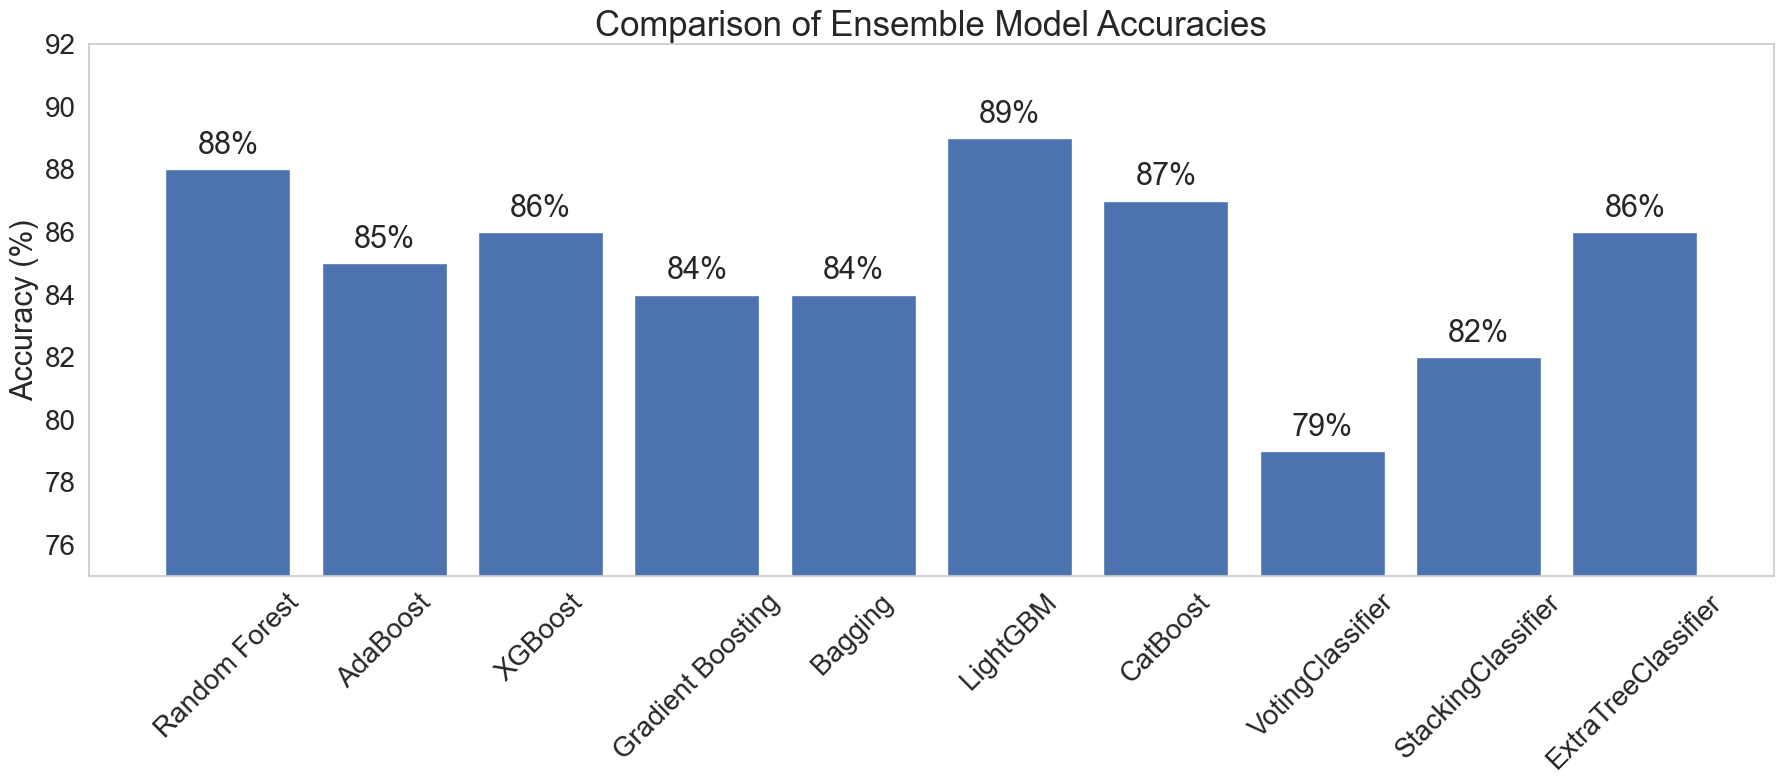

In [26]:
import matplotlib.pyplot as plt

model_names = ['Random Forest', 'AdaBoost', 'XGBoost', 'Gradient Boosting', 'Bagging',
               'LightGBM', 'CatBoost', 'VotingClassifier', 'StackingClassifier', 'ExtraTreeClassifier']
accuracies  = [88, 85, 86, 84, 84, 89, 87, 79, 82, 86]

plt.figure(figsize=(18, 8))
bars = plt.bar(model_names, accuracies)

# Remove grid
plt.grid(False)

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,                 # position of label
        f'{height}%',
        ha='center', va='bottom',
        fontsize=22
    )

plt.ylabel("Accuracy (%)", fontsize=22)
plt.ylim(75, 92)
plt.title("Comparison of Ensemble Model Accuracies", fontsize=25)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()